In [1]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = data.drop(["List Price","IPO_Name","Date","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"], axis=1)

y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)

model = RandomForestRegressor(random_state = 1)
model.fit(X_train ,y_train)
rf_pred = model.predict(X_test)

print(rf_pred[:10])



[ 15.0136  56.7665  66.4123 134.0682 677.2085 110.3045 271.0445 625.5495
 721.7885 230.3885]


In [3]:
comperison = pd.DataFrame({
    "Actual price" : y_test,
    "predicted price" : rf_pred
})
print(comperison)

     Actual price  predicted price
465         10.10          15.0136
441         55.80          56.7665
593         52.13          66.4123
458        110.00         134.0682
41         660.00         677.2085
..            ...              ...
195        360.50         403.5670
135        137.75         136.7170
411        313.00         368.4075
159        163.30         115.3312
250        141.00         115.0155

[131 rows x 2 columns]


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 54.91958091603053
RMSE: 90.44435255087316
R2  : 0.954498726180936


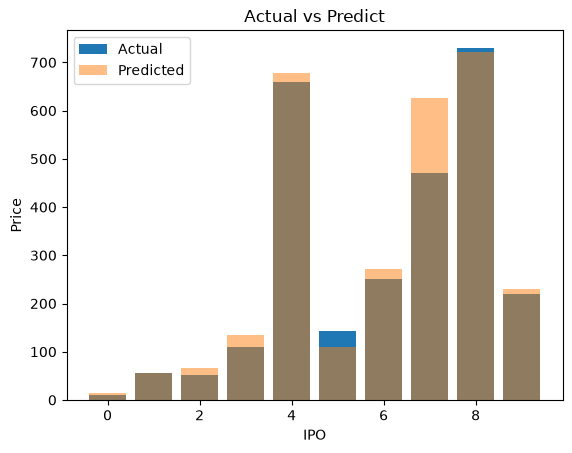

In [5]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), rf_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()

In [6]:
import joblib
joblib.dump(model , "random_forest.pkl")

['random_forest.pkl']